Matrix([
[lk + 1,     -1],
[     1, lk + 1]])

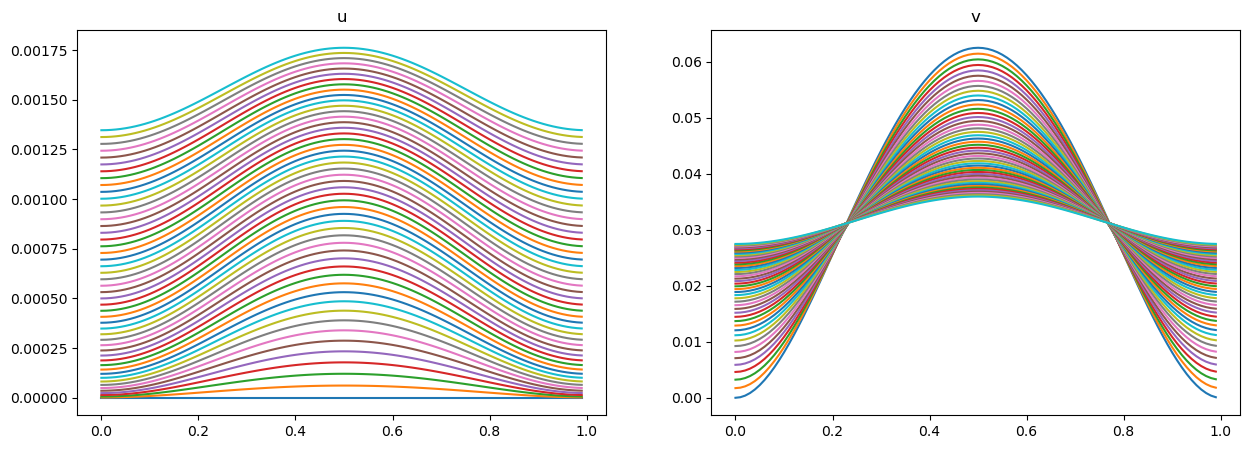

In [7]:
from scipy.fftpack import rfft, irfft
from matplotlib.pylab import plt, log, polyfit
import numpy as np
import sympy as sy

L = 1
N = 100
dx = L/N
T = 0.05
dt = 0.001
X = np.linspace(0,L-dx,N)

lambdak = [0]
for k in np.arange(1,N//2+1) :
	v = (2*np.pi*k/L)**2
	lambdak.append(v)
	lambdak.append(v)

u0 = lambda x : (x-x**2)**3
v0 = lambda x : (x-x**2)**2

U0 = np.zeros(N)#u0(X)
V0 = v0(X)

U0chap = rfft(U0)
V0chap = rfft(V0)

lk, t = sy.symbols('lk, t',real=True)

B = sy.Matrix([[lk+1,-1],[1,lk+1]])
eB = sy.exp(-t*B)
display(B)
eBnump = sy.lambdify([lk,t], eB, 'numpy')

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].set_title('u')
axs[1].set_title('v')

Ulegend = []
Vlegend = []

for t_val in np.arange(0,T,dt) :
	Uchap = np.zeros(U0chap.shape)
	Vchap = np.zeros(V0chap.shape)

	for i in np.arange(len(lambdak)-1) :
		eBt = eBnump(lambdak[i], t_val)
		#print(eBt)
		Uchap[i] = eBt[0, 0] * U0chap[i] + eBt[0, 1] * V0chap[i]
		Vchap[i] = eBt[1, 0] * U0chap[i] + eBt[1, 1] * V0chap[i]

	U = irfft(Uchap)
	V = irfft(Vchap)

	axs[0].plot(X,U)
	axs[1].plot(X,V)
	Ulegend.append(f't = {t_val}')
	Vlegend.append(f't = {t_val}')


#axs[0].legend(Ulegend)
#axs[1].legend(Vlegend)

plt.show()